In [3]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
from torchvision.models import resnet18 # Escolhendo a ResNet18 para começar

# --- 1. CONFIGURAÇÃO E DEFINIÇÃO DAS TRANSFORMAÇÕES ---
# ⚠️ Se for usar a GPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Usando dispositivo: {device}")

# Define as transformações (redimensionar para 32x32 e normalizar para CIFAR-10)
transform = transforms.Compose([
    transforms.ToTensor(), # Converte a imagem para Tensor (necessário para PyTorch)
    # Valores de normalização para o dataset CIFAR-10
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010)) 
])

# --- 2. CARREGAR E PREPARAR DATASETS ---
# O 'download=True' garante que os dados sejam baixados para sua máquina
train_dataset = datasets.CIFAR10(
    root='./data', 
    train=True, 
    download=True, 
    transform=transform
)
test_dataset = datasets.CIFAR10(
    root='./data', 
    train=False, 
    download=True, 
    transform=transform
)

# --- 3. CRIAR DATALOADERS ---
# O batch_size é o que você pode ajustar dependendo da VRAM da sua 3060 Ti (8GB)
# 64 ou 128 geralmente funciona bem para CIFAR-10 com ResNet.
BATCH_SIZE = 128 

train_loader = DataLoader(
    train_dataset, 
    batch_size=BATCH_SIZE, 
    shuffle=True, 
    num_workers=4 # Usa 4 processos para carregar dados mais rápido
)
test_loader = DataLoader(
    test_dataset, 
    batch_size=BATCH_SIZE, 
    shuffle=False, 
    num_workers=4
)

# --- 4. CONFIGURAR MODELO PARA GPU ---
model = resnet18(pretrained=True) # Começa com pesos pré-treinados
num_ftrs = model.fc.in_features
model.fc = nn.Linear(num_ftrs, 10) # Altera a última camada para 10 classes (CIFAR-10)
model = model.to(device) # MOVE O MODELO PARA A SUA RTX 3060 TI!

Usando dispositivo: cuda


100%|██████████| 170M/170M [00:27<00:00, 6.29MB/s] 
/opt/conda/envs/bert/lib/python3.12/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/opt/conda/envs/bert/lib/python3.12/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth
100%|██████████| 44.7M/44.7M [00:00<00:00, 58.8MB/s]


In [4]:
# Importações necessárias
import torch.nn as nn
import torch.optim as optim
import time
import matplotlib.pyplot as plt

# --- 5. DEFINIR FUNÇÃO DE PERDA, OTIMIZADOR E TREINAMENTO ---

# Função de Perda: Cross-Entropy é padrão para classificação
criterion = nn.CrossEntropyLoss()

# Otimizador: Stochastic Gradient Descent (SGD) é um bom ponto de partida
# Definimos uma taxa de aprendizado (lr) e momentum
optimizer = optim.SGD(model.parameters(), lr=0.001, momentum=0.9)

def train(model, device, train_loader, optimizer, epoch):
    """Função para treinar o modelo por uma época."""
    model.train()  # Coloca o modelo em modo de treinamento
    running_loss = 0.0
    start_time = time.time()
    
    # Itera sobre os lotes (batches) de dados
    for batch_idx, (data, target) in enumerate(train_loader):
        # Move dados e rótulos para a GPU (RTX 3060 Ti)
        data, target = data.to(device), target.to(device)

        # 1. Zera os gradientes (necessário em cada iteração)
        optimizer.zero_grad()

        # 2. Forward pass: calcula a saída do modelo
        output = model(data)

        # 3. Calcula a perda (diferença entre saída e alvo)
        loss = criterion(output, target)

        # 4. Backward pass: calcula os gradientes
        loss.backward()

        # 5. Atualiza os pesos do modelo
        optimizer.step()

        running_loss += loss.item()
        
        # Opcional: imprimir o progresso
        if batch_idx % 100 == 99:    
            print(f"Epoch {epoch} | Batch {batch_idx+1:5d} | Loss: {running_loss / 100:.3f}")
            running_loss = 0.0
    
    end_time = time.time()
    print(f"Epoch {epoch} concluída em {end_time - start_time:.2f} segundos.")


# --- 6. EXECUTAR O LOOP DE TREINAMENTO ---
print("\nIniciando o Treinamento...")
NUM_EPOCHS = 5 # Defina quantas vezes você quer iterar sobre o dataset completo

for epoch in range(1, NUM_EPOCHS + 1):
    train(model, device, train_loader, optimizer, epoch)

print("Treinamento concluído!")


Iniciando o Treinamento...
Epoch 1 | Batch   100 | Loss: 1.644
Epoch 1 | Batch   200 | Loss: 1.131
Epoch 1 | Batch   300 | Loss: 0.958
Epoch 1 concluída em 4.15 segundos.
Epoch 2 | Batch   100 | Loss: 0.722
Epoch 2 | Batch   200 | Loss: 0.701
Epoch 2 | Batch   300 | Loss: 0.684
Epoch 2 concluída em 3.72 segundos.
Epoch 3 | Batch   100 | Loss: 0.510
Epoch 3 | Batch   200 | Loss: 0.519
Epoch 3 | Batch   300 | Loss: 0.529
Epoch 3 concluída em 3.67 segundos.
Epoch 4 | Batch   100 | Loss: 0.377
Epoch 4 | Batch   200 | Loss: 0.395
Epoch 4 | Batch   300 | Loss: 0.399
Epoch 4 concluída em 3.67 segundos.
Epoch 5 | Batch   100 | Loss: 0.288
Epoch 5 | Batch   200 | Loss: 0.299
Epoch 5 | Batch   300 | Loss: 0.304
Epoch 5 concluída em 3.67 segundos.
Treinamento concluído!



Acurácia no conjunto de Teste: 78.37 %


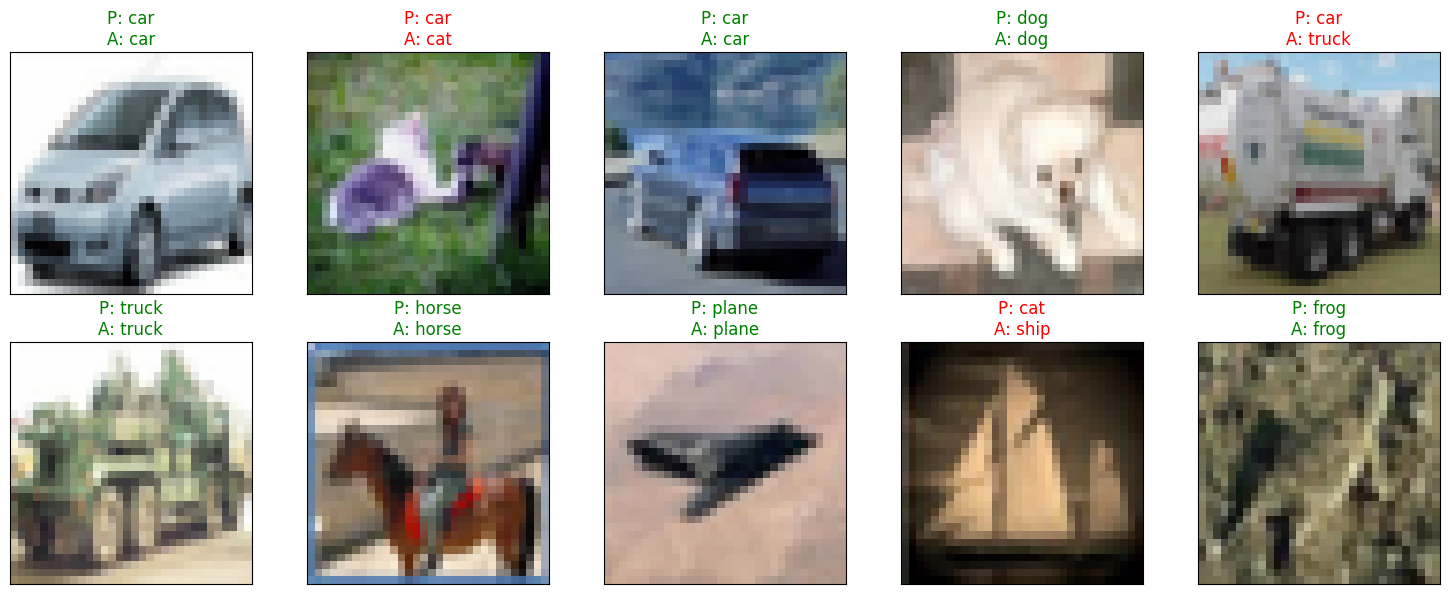

In [5]:
# Importações adicionais
import numpy as np
import random

# --- 7. AVALIAÇÃO E INFERÊNCIA ---

def test_model(model, device, test_loader):
    """Avalia a acurácia do modelo no conjunto de testes."""
    model.eval() # Coloca o modelo em modo de avaliação (desliga dropout, etc.)
    correct = 0
    total = 0
    
    # Não precisamos calcular gradientes durante a inferência
    with torch.no_grad():
        for data, target in test_loader:
            data, target = data.to(device), target.to(device)
            output = model(data)
            
            # Pega o índice da classe com maior probabilidade
            _, predicted = torch.max(output.data, 1)
            total += target.size(0)
            correct += (predicted == target).sum().item()

    accuracy = 100 * correct / total
    print(f'\nAcurácia no conjunto de Teste: {accuracy:.2f} %')
    return accuracy

# Executar a avaliação
test_model(model, device, test_loader)

# --- 8. VISUALIZAÇÃO DA INFERÊNCIA ---

# Define as classes do dataset CIFAR-10
classes = ('plane', 'car', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck')

def imshow(img):
    """Função auxiliar para exibir uma imagem."""
    # Desnormalizar: Inverte o processo de normalização (necessário para exibição correta)
    # Valores de normalização usados no passo 1.
    mean = np.array([0.4914, 0.4822, 0.4465])
    std = np.array([0.2023, 0.1994, 0.2010])
    img = img.numpy().transpose((1, 2, 0)) # Transforma de (C, H, W) para (H, W, C)
    img = std * img + mean
    img = np.clip(img, 0, 1) # Garante que os valores estejam entre 0 e 1
    return img

def visualize_inference(model, device, test_dataset):
    """Exibe 10 imagens aleatórias com suas previsões."""
    model.eval()
    fig = plt.figure(figsize=(15, 6))
    
    # Seleciona 10 índices aleatórios do dataset de teste
    indices = random.sample(range(len(test_dataset)), 10)
    
    with torch.no_grad():
        for i, idx in enumerate(indices):
            # Obtém a imagem e o rótulo
            image_tensor, actual_label_id = test_dataset[idx]
            
            # Adiciona dimensão de lote e move para GPU
            image_input = image_tensor.unsqueeze(0).to(device)
            
            # Faz a previsão
            output = model(image_input)
            _, predicted_label_id = torch.max(output.data, 1)
            
            # Converte IDs para nomes de classe
            predicted_class = classes[predicted_label_id.item()]
            actual_class = classes[actual_label_id]
            
            # Configura o subplot
            ax = fig.add_subplot(2, 5, i + 1, xticks=[], yticks=[])
            
            # Exibe a imagem (usando a função de desnormalização)
            plt.imshow(imshow(image_tensor.cpu()))
            
            # Define o título da imagem
            color = "green" if predicted_class == actual_class else "red"
            ax.set_title(f"P: {predicted_class}\nA: {actual_class}", color=color)

    plt.tight_layout()
    plt.show()

# Executar a visualização da inferência
visualize_inference(model, device, test_dataset)